In [1]:
import zipfile
import os

zip_path = "/content/daily+and+sports+activities.zip"
extract_path = "/content/DASD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['data']


In [2]:
pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.5 MB/s eta 0:00:00


In [3]:
from pyts.image import RecurrencePlot
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import zoom
import numpy as np

sample_file = "/content/DASD/data/a01/p1/s01.txt"

signal_data = np.loadtxt(
    sample_file,
    delimiter=','
)

scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

normalized_sample = scaler.fit_transform(
    signal_data
)

rp = RecurrencePlot()

rp_images = []

for ch in range(normalized_sample.shape[1]):

    signal = normalized_sample[:, ch]

    signal = signal.reshape(1, -1)

    rp_image = rp.fit_transform(
        signal
    )[0]

    # resize 125 -> 128
    rp_image = zoom(
        rp_image,
        (128/125, 128/125),
        order=1
    )

    rp_images.append(
        rp_image
    )

rp_tensor = np.stack(
    rp_images,
    axis=-1
)

print("RP Tensor Shape:", rp_tensor.shape)

RP Tensor Shape: (128, 128, 45)


In [4]:
import os
import numpy as np
from pyts.image import RecurrencePlot
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import zoom

dataset_path = "/content/DASD/data"
save_path = "/content/RP128_DATA"

os.makedirs(save_path, exist_ok=True)

rp = RecurrencePlot()

sample_count = 0

activities = sorted(os.listdir(dataset_path))

for activity in activities:

    activity_path = os.path.join(
        dataset_path,
        activity
    )

    participants = sorted(
        os.listdir(activity_path)
    )

    for participant in participants:

        participant_path = os.path.join(
            activity_path,
            participant
        )

        files = sorted(
            os.listdir(participant_path)
        )

        for file in files:

            file_path = os.path.join(
                participant_path,
                file
            )

            signal_data = np.loadtxt(
                file_path,
                delimiter=','
            )

            scaler = MinMaxScaler(
                feature_range=(-1, 1)
            )

            normalized_signal = scaler.fit_transform(
                signal_data
            )

            rp_channels = []

            for ch in range(
                normalized_signal.shape[1]
            ):

                signal = normalized_signal[:, ch]

                signal = signal.reshape(1, -1)

                rp_image = rp.fit_transform(
                    signal
                )[0]

                rp_image = zoom(
                    rp_image,
                    (128/125, 128/125),
                    order=1
                )

                rp_channels.append(
                    rp_image
                )

            rp_tensor = np.stack(
                rp_channels,
                axis=-1
            )

            save_name = (
                f"{activity}_{participant}_{file[:-4]}.npy"
            )

            np.save(
                os.path.join(
                    save_path,
                    save_name
                ),
                rp_tensor.astype(
                    np.float32
                )
            )

            sample_count += 1

    print(f"Finished {activity}")

print("\nTotal Samples:", sample_count)

Finished a01
Finished a02
Finished a03
Finished a04
Finished a05
Finished a06
Finished a07
Finished a08
Finished a09
Finished a10
Finished a11
Finished a12
Finished a13
Finished a14
Finished a15
Finished a16
Finished a17
Finished a18
Finished a19

Total Samples: 9120


In [6]:
import os

data_path = "/content/RP128_DATA"

all_files = sorted(os.listdir(data_path))

file_paths = []
labels = []

for file in all_files:

    file_path = os.path.join(data_path, file)

    activity = file.split("_")[0]

    label = int(activity[1:]) - 1

    file_paths.append(file_path)
    labels.append(label)

print("Total Files:", len(file_paths))
print("Example:", file_paths[0])
print("Label:", labels[0])

Total Files: 9120
Example: /content/RP128_DATA/a01_p1_s01.npy
Label: 0


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 7296
Test : 1824


In [8]:
import torch
from torch.utils.data import Dataset
import numpy as np

class RP128Dataset(Dataset):

    def __init__(self, file_paths, labels):

        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):

        return len(self.file_paths)

    def __getitem__(self, idx):

        x = np.load(self.file_paths[idx])

        # (128,128,45) -> (45,128,128)
        x = np.transpose(x, (2, 0, 1))

        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return x, y

In [9]:
train_dataset = RP128Dataset(
    X_train,
    y_train
)

test_dataset = RP128Dataset(
    X_test,
    y_test
)

print(len(train_dataset))
print(len(test_dataset))

7296
1824


In [10]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([8, 45, 128, 128])
torch.Size([8])


In [13]:
import torch
import torch.nn as nn
import timm
import numpy as np


# ---------- Positional Embeddings ----------

def get_1d_sincos_pos_embed(embed_dim, pos):

    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / (10000 ** omega)

    pos = pos.reshape(-1)

    out = np.einsum('m,d->md', pos, omega)

    return np.concatenate(
        [np.sin(out), np.cos(out)],
        axis=1
    )


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):

    emb_h = get_1d_sincos_pos_embed(
        embed_dim // 2,
        grid[0]
    )

    emb_w = get_1d_sincos_pos_embed(
        embed_dim // 2,
        grid[1]
    )

    return np.concatenate(
        [emb_h, emb_w],
        axis=1
    )


def get_2d_sincos_pos_embed(embed_dim, grid_size):

    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)

    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])

    pos_embed = get_2d_sincos_pos_embed_from_grid(
        embed_dim,
        grid
    )

    return torch.from_numpy(pos_embed).float()


# ---------- SimpleViT ----------

class SimpleViT19Class(nn.Module):

    def __init__(
        self,
        image_size=128,
        patch_size=16,
        in_channels=45
    ):

        super().__init__()

        self.num_classes = 19

        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0,
            drop_rate=0.1,
            drop_path_rate=0.1
        )

        # Modify input channels
        old = self.vit.patch_embed.proj

        self.vit.patch_embed.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=(old.bias is not None)
        )

        with torch.no_grad():

            self.vit.patch_embed.proj.weight.zero_()

            self.vit.patch_embed.proj.weight[:, :3] = old.weight

            if old.bias is not None:
                self.vit.patch_embed.proj.bias.copy_(old.bias)

        # Remove CLS token
        self.vit.cls_token = None
        self.vit.num_tokens = 0

        # Positional embedding
        grid_size = image_size // patch_size

        embed_dim = self.vit.embed_dim

        pos_embed = get_2d_sincos_pos_embed(
            embed_dim,
            grid_size
        )

        self.register_buffer(
            "pos_embed",
            pos_embed.unsqueeze(0),
            persistent=False
        )

        # Classification head
        self.head = nn.Linear(
            embed_dim,
            self.num_classes
        )

        self.vit.patch_embed.img_size = (
            image_size,
            image_size
        )

        self.vit.patch_embed.strict_img_size = False

    def forward(self, x):

        x = self.vit.patch_embed(x)

        # Compatible with different timm versions
        if x.ndim == 4:
            x = x.flatten(2).transpose(1, 2)

        x = x + self.pos_embed

        x = self.vit.pos_drop(x)

        for blk in self.vit.blocks:
            x = blk(x)

        x = self.vit.norm(x)

        x = x.mean(dim=1)

        x = self.head(x)

        return x

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleViT19Class(
    image_size=128,
    patch_size=16,
    in_channels=45
).to(device)

print("Model created!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model created!


In [16]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=15
)

In [17]:
from tqdm import tqdm
import torch

num_epochs = 15

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        accuracy = 100.0 * correct / total

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{accuracy:.2f}"
        )

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100.0 * correct / total

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_acc:.2f}%")

100%|██████████| 912/912 [02:13<00:00,  6.83it/s, accuracy=51.37, loss=0.2798]



Epoch 1/15
Train Loss: 1.4481
Train Accuracy: 51.37%


100%|██████████| 912/912 [02:01<00:00,  7.50it/s, accuracy=85.70, loss=0.2323]



Epoch 2/15
Train Loss: 0.3985
Train Accuracy: 85.70%


100%|██████████| 912/912 [02:01<00:00,  7.50it/s, accuracy=92.58, loss=0.0035]


...


Epoch 13/15
Train Loss: 0.0001
Train Accuracy: 100.00%


100%|██████████| 912/912 [02:03<00:00,  7.37it/s, accuracy=100.00, loss=0.0000]



Epoch 14/15
Train Loss: 0.0001
Train Accuracy: 100.00%


100%|██████████| 912/912 [02:06<00:00,  7.19it/s, accuracy=100.00, loss=0.0000]


Epoch 15/15
Train Loss: 0.0000
Train Accuracy: 100.00%


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

Accuracy : 0.9649122807017544
Precision: 0.9660539172781398
Recall   : 0.9649122807017544
F1 Score : 0.9650551207835341


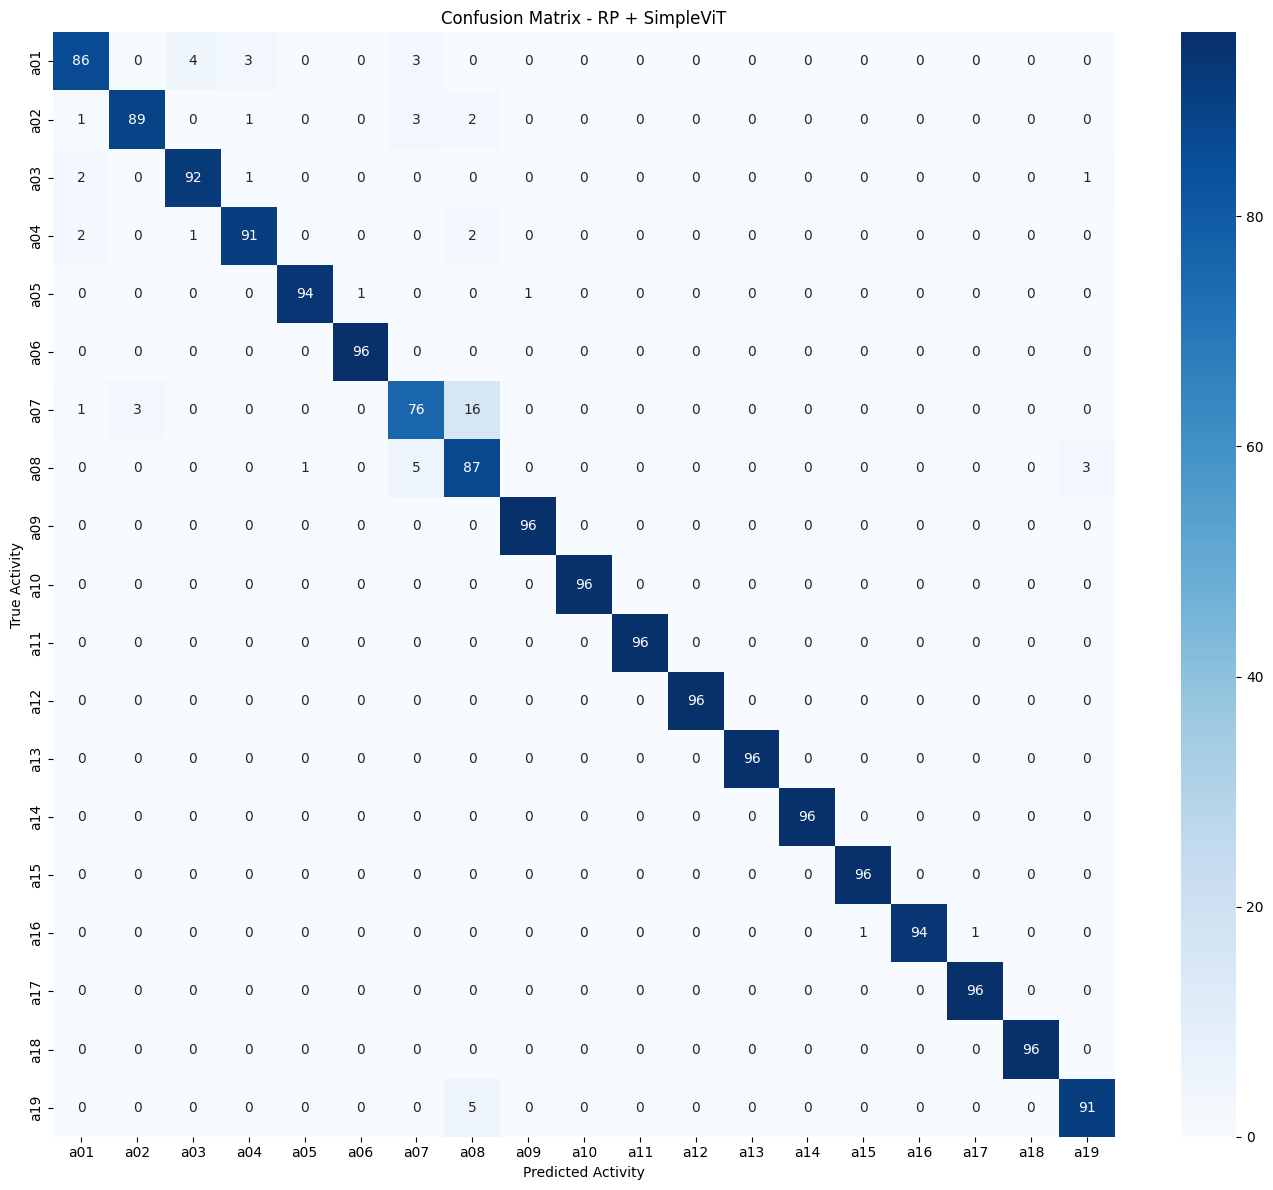

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cm = confusion_matrix(y_true, y_pred)

classes = [f"a{i:02d}" for i in range(1, 20)]

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - RP + SimpleViT")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")

plt.tight_layout()
plt.show()